<a href="https://colab.research.google.com/github/KIRTIRAJ4327/30days-AI-challenge/blob/main/Copy_of_RealEstatePrice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#!/usr/bin/env python3

**NextProperty AI - Real Estate Price Prediction Analysis**

Complete Implementation with Step-by-Step Workflow  

**Authors:** NextProperty AI Team
Date: May 2025

**Purpose:** Comprehensive real estate dataset analysis and machine learning pipeline


**Initial Data Loading and Overview**

In [ ]:
!pip install statsmodels
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.cluster import KMeans
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import re
import warnings
warnings.filterwarnings('ignore')



In [ ]:
print("="*80)
print("NEXTPROPERTY AI - REAL ESTATE PRICE PREDICTION ANALYSIS")
print("="*80)

NEXTPROPERTY AI - REAL ESTATE PRICE PREDICTION ANALYSIS


In [ ]:
# Load the dataset
print("Loading real estate dataset...")
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/realEstate.csv')  # Update path as needed

print(f"✓ Dataset loaded successfully")
print(f"  - Shape: {df.shape}")
print(f"  - Total columns: {len(df.columns)}")
print(f"  - Memory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")


Loading real estate dataset...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Dataset loaded successfully
  - Shape: (49551, 162)
  - Total columns: 162
  - Memory usage: 60.58 MB


In [ ]:
# Display basic information about the dataset
print(f"\nData types distribution:")
print(df.dtypes.value_counts())

print(f"\nFirst 10 columns: {df.columns[:10].tolist()}")
print(f"Last 10 columns: {df.columns[-10:].tolist()}")


Data types distribution:
object     112
float64     40
int64        8
bool         2
Name: count, dtype: int64

First 10 columns: ['property_id', 'PostID', 'Offices', 'Agents', 'Board', 'ListingID', 'DdfListingID', 'LastUpdated', 'Latitude', 'Longitude']
Last 10 columns: ['CommunityName', 'Neighbourhood', 'Subdivision', 'Utilities', 'Parking', 'OpenHouse', 'LiveStream', 'AlternateURL', 'CustomListing', 'Sold']


- Understanding the dataset structure is crucial before any analysis
- Knowing data types helps plan appropriate preprocessing strategies
- Memory usage awareness is important for large datasets
- Column inspection helps identify key features for real estate analysis

# STEP 2: COMPREHENSIVE MISSING VALUE ANALYSIS

In [ ]:
# Calculate missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_percent
}).sort_values('Missing_Percentage', ascending=False)

# Categorize columns by missing value percentage
missing_categories = {
    'Complete (0% missing)': sum(missing_percent == 0),
    'Low missing (0-10%)': sum((missing_percent > 0) & (missing_percent <= 10)),
    'Medium missing (10-50%)': sum((missing_percent > 10) & (missing_percent <= 50)),
    'High missing (50-90%)': sum((missing_percent > 50) & (missing_percent <= 90)),
    'Very high missing (90-100%)': sum((missing_percent > 90) & (missing_percent < 100)),
    'Completely empty (100%)': sum(missing_percent == 100)
}

print("Missing value distribution across columns:")
for category, count in missing_categories.items():
    print(f"  {category}: {count} columns")

# Show top 15 columns with highest missing values
missing_columns = missing_df[missing_df['Missing_Count'] > 0]
print(f"\nColumns with missing values: {len(missing_columns)}")
print("\nTop 15 columns with highest missing percentages:")
print(missing_columns.head(15))

# Identify key real estate columns and their missing value status
key_real_estate_columns = [
    'Price', 'BedroomsTotal', 'BathroomTotal', 'PropertyType', 'City', 'Province',
    'PostalCode', 'Latitude', 'Longitude', 'SizeTotalText', 'SizeTotal',
    'Features', 'HeatingType', 'CoolingType', 'CommunityName'
]

print(f"\nMissing value status for key real estate columns:")
for col in key_real_estate_columns:
    if col in df.columns:
        pct_missing = df[col].isnull().mean() * 100
        status = "✓ Good" if pct_missing < 10 else "⚠ Moderate" if pct_missing < 50 else "✗ Poor"
        print(f"  {col}: {pct_missing:.1f}% missing {status}")
    else:
        print(f"  {col}: Not in dataset ✗")

Missing value distribution across columns:
  Complete (0% missing): 33 columns
  Low missing (0-10%): 7 columns
  Medium missing (10-50%): 22 columns
  High missing (50-90%): 26 columns
  Very high missing (90-100%): 46 columns
  Completely empty (100%): 28 columns

Columns with missing values: 129

Top 15 columns with highest missing percentages:
                        Missing_Count  Missing_Percentage
LeaseTermRemaining              49551               100.0
LoadingType                     49551               100.0
IrrigationType                  49551               100.0
Machinery                       49551               100.0
LeaseTermRemainingFreq          49551               100.0
StoreFront                      49551               100.0
Divisible                       49551               100.0
FrontsOn                        49551               100.0
ClearCeilingHeight              49551               100.0
Anchor                          49551               100.0
OperatingSin

- Missing values significantly impact model performance and data quality
- Understanding missing patterns helps prioritize which columns to focus on
- Categorizing columns by completeness guides feature selection strategy
- Key real estate columns assessment ensures we have essential data for modeling

# STEP 3: STRATEGIC COLUMN SELECTION AND DATA CLEANING

In [ ]:
# Remove columns with >90% missing values (they provide little value)
high_missing_cols = missing_df[missing_df['Missing_Percentage'] > 90].index.tolist()
print(f"Removing {len(high_missing_cols)} columns with >90% missing values")

# Keep essential columns even if they have some missing values
essential_columns = [
    'property_id', 'Price', 'PropertyType', 'City', 'Province', 'PostalCode',
    'Latitude', 'Longitude', 'BedroomsTotal', 'BathroomTotal', 'SizeTotalText',
    'SizeTotal', 'Features', 'HeatingType', 'CoolingType', 'CommunityName',
    'ZoningDescription', 'OwnershipType', 'ParkingSpaceTotal', 'StoriesTotal',
    'Amenities', 'Appliances', 'LandAmenities', 'FireplaceTotal', 'HalfBathTotal',
    'ExteriorFinish', 'BasementType', 'FoundationType', 'RoofMaterial'
]

# Select columns for analysis (essential columns + others with <70% missing)
medium_missing_cols = missing_df[
    (missing_df['Missing_Percentage'] <= 70) &
    (~missing_df.index.isin(high_missing_cols))
].index.tolist()

selected_columns = list(set(essential_columns + medium_missing_cols))
selected_columns = [col for col in selected_columns if col in df.columns]

# Create working dataset
df_work = df[selected_columns].copy()
print(f"✓ Selected {len(selected_columns)} columns for analysis")
print(f"  - Reduced from {df.shape[1]} to {df_work.shape[1]} columns")
print(f"  - Dataset shape: {df_work.shape}")


Removing 74 columns with >90% missing values
✓ Selected 74 columns for analysis
  - Reduced from 162 to 74 columns
  - Dataset shape: (49551, 74)


- Focusing on high-quality columns improves model performance
- Removing columns with >90% missing values reduces noise
- Essential real estate columns are preserved regardless of missing values
- Strategic selection balances data quality with feature richness

# STEP 4: TEXT DATA EXTRACTION AND FEATURE CREATION

In [ ]:
# Extract numeric size from SizeTotalText
def extract_size(text):
    """Extract square footage from text descriptions"""
    if pd.isna(text):
        return np.nan

    text_str = str(text).lower()

    # Look for square footage patterns
    sq_ft_patterns = [
        r'(\d{1,3}(?:,\d{3})*(?:\.\d+)?)\s*(?:sq\.?\s*ft\.?|square\s*feet)',
        r'(\d{1,3}(?:,\d{3})*(?:\.\d+)?)\s*sqft',
        r'(\d{1,3}(?:,\d{3})*(?:\.\d+)?)\s*sq'
    ]

    for pattern in sq_ft_patterns:
        matches = re.findall(pattern, text_str)
        if matches:
            return float(matches[0].replace(',', ''))

    # Look for general numeric patterns as fallback
    general_pattern = r'(\d{1,3}(?:,\d{3})*(?:\.\d+)?)'
    matches = re.findall(general_pattern, text_str)
    if matches:
        # Take the largest number as likely to be square footage
        numbers = [float(m.replace(',', '')) for m in matches]
        return max(numbers) if max(numbers) > 100 else np.nan  # Reasonable size filter

    return np.nan

if 'SizeTotalText' in df_work.columns:
    df_work['Size_Extracted'] = df_work['SizeTotalText'].apply(extract_size)
    extracted_count = df_work['Size_Extracted'].notna().sum()
    print(f"✓ Extracted size information for {extracted_count} properties")
else:
    print("⚠ SizeTotalText column not available for size extraction")

# Extract binary features from Features column
if 'Features' in df_work.columns:
    feature_keywords = [
        'renovated', 'updated', 'garage', 'pool', 'fireplace',
        'finished basement', 'hardwood', 'granite', 'stainless',
        'modern', 'luxury', 'new', 'corner', 'balcony'
    ]

    for keyword in feature_keywords:
        col_name = f'Has_{keyword.replace(" ", "_")}'
        df_work[col_name] = df_work['Features'].str.contains(
            keyword, case=False, na=False
        ).astype(int)

    print(f"✓ Created {len(feature_keywords)} binary feature indicators")
else:
    print("⚠ Features column not available for feature extraction")

✓ Extracted size information for 18596 properties
✓ Created 14 binary feature indicators


- Text columns contain valuable information that models can't directly use
- Extracting structured data from unstructured text increases predictive power
- Binary feature indicators capture important property characteristics
- Standardized size extraction provides consistent measurement units

# STEP 5: SMART MISSING VALUE IMPUTATION

In [ ]:
# Property type-specific imputation for key characteristics
property_specific_columns = ['BedroomsTotal', 'BathroomTotal', 'HeatingType', 'CoolingType']

for column in property_specific_columns:
    if column not in df_work.columns:
        continue

    missing_before = df_work[column].isna().sum()
    if missing_before == 0:
        continue

    if 'PropertyType' in df_work.columns:
        # For numeric columns, use median by property type
        if df_work[column].dtype in ['int64', 'float64']:
            df_work[column] = df_work.groupby('PropertyType')[column].transform(
                lambda x: x.fillna(x.median()) if not x.empty else x
            )
        else:
            # For categorical columns, use mode by property type
            prop_type_modes = {}
            for prop_type in df_work['PropertyType'].dropna().unique():
                subset = df_work[df_work['PropertyType'] == prop_type][column]
                if not subset.empty and not subset.dropna().empty:
                    prop_type_modes[prop_type] = subset.mode().iloc[0]

            for prop_type, mode_val in prop_type_modes.items():
                mask = (df_work['PropertyType'] == prop_type) & df_work[column].isna()
                df_work.loc[mask, column] = mode_val

    # Fill any remaining missing values
    if df_work[column].dtype in ['int64', 'float64']:
        df_work[column] = df_work[column].fillna(df_work[column].median())
    else:
        if not df_work[column].dropna().empty:
            df_work[column] = df_work[column].fillna(df_work[column].mode().iloc[0])
        else:
            df_work[column] = df_work[column].fillna("Unknown")

    missing_after = df_work[column].isna().sum()
    print(f"✓ Imputed {column}: {missing_before - missing_after} missing values")

# Location-based imputation for neighborhood features
location_columns = ['CommunityName', 'ZoningDescription']

for column in location_columns:
    if column not in df_work.columns:
        continue

    missing_before = df_work[column].isna().sum()
    if missing_before == 0:
        continue

    if 'City' in df_work.columns:
        # City-based mode imputation
        city_modes = {}
        for city in df_work['City'].dropna().unique():
            subset = df_work[df_work['City'] == city][column]
            if not subset.empty and not subset.dropna().empty:
                city_modes[city] = subset.mode().iloc[0]

        for city, mode_val in city_modes.items():
            mask = (df_work['City'] == city) & df_work[column].isna()
            df_work.loc[mask, column] = mode_val

    # Fill remaining with global mode or "Unknown"
    if not df_work[column].dropna().empty:
        df_work[column] = df_work[column].fillna(df_work[column].mode().iloc[0])
    else:
        df_work[column] = df_work[column].fillna("Unknown")

    missing_after = df_work[column].isna().sum()
    print(f"✓ Imputed {column}: {missing_before - missing_after} missing values")

# Simple imputation for remaining columns
remaining_missing = df_work.isnull().sum()
remaining_cols = remaining_missing[remaining_missing > 0].index.tolist()

if remaining_cols:
    print(f"\nApplying simple imputation to {len(remaining_cols)} remaining columns...")
    for col in remaining_cols:
        if df_work[col].dtype in ['int64', 'float64']:
            df_work[col] = df_work[col].fillna(df_work[col].median())
        else:
            if not df_work[col].dropna().empty:
                df_work[col] = df_work[col].fillna(df_work[col].mode().iloc[0])
            else:
                df_work[col] = df_work[col].fillna("Unknown")

print(f"✓ Final missing values: {df_work.isnull().sum().sum()}")

✓ Imputed HeatingType: 6590 missing values
✓ Imputed CoolingType: 11453 missing values
✓ Imputed CommunityName: 13310 missing values
✓ Imputed ZoningDescription: 22367 missing values

Applying simple imputation to 38 remaining columns...
✓ Final missing values: 0


- Context-aware imputation preserves relationships between variables
- Property type-specific imputation maintains realistic patterns
- Location-based imputation respects geographic clustering of features
- Systematic approach ensures no missing values remain for modeling

# STEP 6: ADVANCED FEATURE ENGINEERING

In [ ]:
# Create derived features
created_features = []

# Price per square foot
if all(col in df_work.columns for col in ['Price', 'Size_Extracted']):
    mask = (df_work['Size_Extracted'] > 0) & df_work['Price'].notna()
    if mask.any():
        df_work.loc[mask, 'Price_Per_SqFt'] = (
            df_work.loc[mask, 'Price'] / df_work.loc[mask, 'Size_Extracted']
        )
        created_features.append('Price_Per_SqFt')
        print(f"✓ Created Price_Per_SqFt for {mask.sum()} properties")

# Total rooms
if all(col in df_work.columns for col in ['BedroomsTotal', 'BathroomTotal']):
    df_work['TotalRooms'] = df_work['BedroomsTotal'] + df_work['BathroomTotal']
    created_features.append('TotalRooms')
    print(f"✓ Created TotalRooms feature")

# Bedroom to bathroom ratio
if all(col in df_work.columns for col in ['BedroomsTotal', 'BathroomTotal']):
    mask = df_work['BathroomTotal'] > 0
    if mask.any():
        df_work.loc[mask, 'Bed_Bath_Ratio'] = (
            df_work.loc[mask, 'BedroomsTotal'] / df_work.loc[mask, 'BathroomTotal']
        )
        created_features.append('Bed_Bath_Ratio')
        print(f"✓ Created Bed_Bath_Ratio for {mask.sum()} properties")

# Distance to Toronto (major city reference point)
if all(col in df_work.columns for col in ['Latitude', 'Longitude']):
    def haversine_distance(lat1, lon1, lat2, lon2):
        """Calculate distance between coordinates in kilometers"""
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        c = 2 * np.arcsin(np.sqrt(a))
        r = 6371  # Radius of earth in kilometers
        return c * r

    toronto_center = (43.6532, -79.3832)
    mask = df_work['Latitude'].notna() & df_work['Longitude'].notna()
    if mask.any():
        df_work.loc[mask, 'Distance_To_Toronto'] = haversine_distance(
            df_work.loc[mask, 'Latitude'], df_work.loc[mask, 'Longitude'],
            toronto_center[0], toronto_center[1]
        )
        created_features.append('Distance_To_Toronto')
        print(f"✓ Created Distance_To_Toronto for {mask.sum()} properties")

# Geographic clustering
if all(col in df_work.columns for col in ['Latitude', 'Longitude']):
    coords_data = df_work[['Latitude', 'Longitude']].dropna()
    if len(coords_data) > 10:  # Ensure we have enough data for clustering
        kmeans = KMeans(n_clusters=min(15, len(coords_data)//100), random_state=42)
        cluster_labels = kmeans.fit_predict(coords_data)

        # Map clusters back to original dataframe
        df_work['Geo_Zone'] = np.nan
        df_work.loc[coords_data.index, 'Geo_Zone'] = cluster_labels
        df_work['Geo_Zone'] = df_work['Geo_Zone'].fillna(-1).astype(int)

        created_features.append('Geo_Zone')
        print(f"✓ Created Geo_Zone feature with {len(np.unique(cluster_labels))} clusters")

print(f"\n✓ Total new features created: {len(created_features)}")

✓ Created Price_Per_SqFt for 49545 properties
✓ Created TotalRooms feature
✓ Created Bed_Bath_Ratio for 38596 properties
✓ Created Distance_To_Toronto for 49551 properties
✓ Created Geo_Zone feature with 15 clusters

✓ Total new features created: 5


- Derived features often have stronger predictive power than raw data
- Price per square foot is a standard real estate valuation metric
- Room ratios capture property layout efficiency
- Distance features capture location premiums/discounts
- Geographic clustering groups similar neighborhoods

# STEP 7: EXPLORATORY DATA ANALYSIS AND VISUALIZATION

Summary statistics for key numeric features:
              Price  BedroomsTotal  BathroomTotal  Size_Extracted  \
count  4.955100e+04   49551.000000   49551.000000    4.955100e+04   
mean   8.268296e+05       2.389013       1.903312    3.462823e+02   
std    1.641368e+06       1.978152       1.595932    3.010117e+04   
min    0.000000e+00       0.000000       0.000000    0.000000e+00   
25%    0.000000e+00       0.000000       1.000000    1.424400e+02   
50%    5.980000e+05       2.000000       2.000000    1.424400e+02   
75%    9.980000e+05       4.000000       3.000000    1.424400e+02   
max    7.212800e+07      68.000000      36.000000    6.695813e+06   

       Price_Per_SqFt  Distance_To_Toronto    TotalRooms  
count    49545.000000         49551.000000  49551.000000  
mean      5263.612871           122.330780      4.292325  
std       9043.547636           183.984035      3.376444  
min          0.000000             0.195592      0.000000  
25%          0.000000            27.27

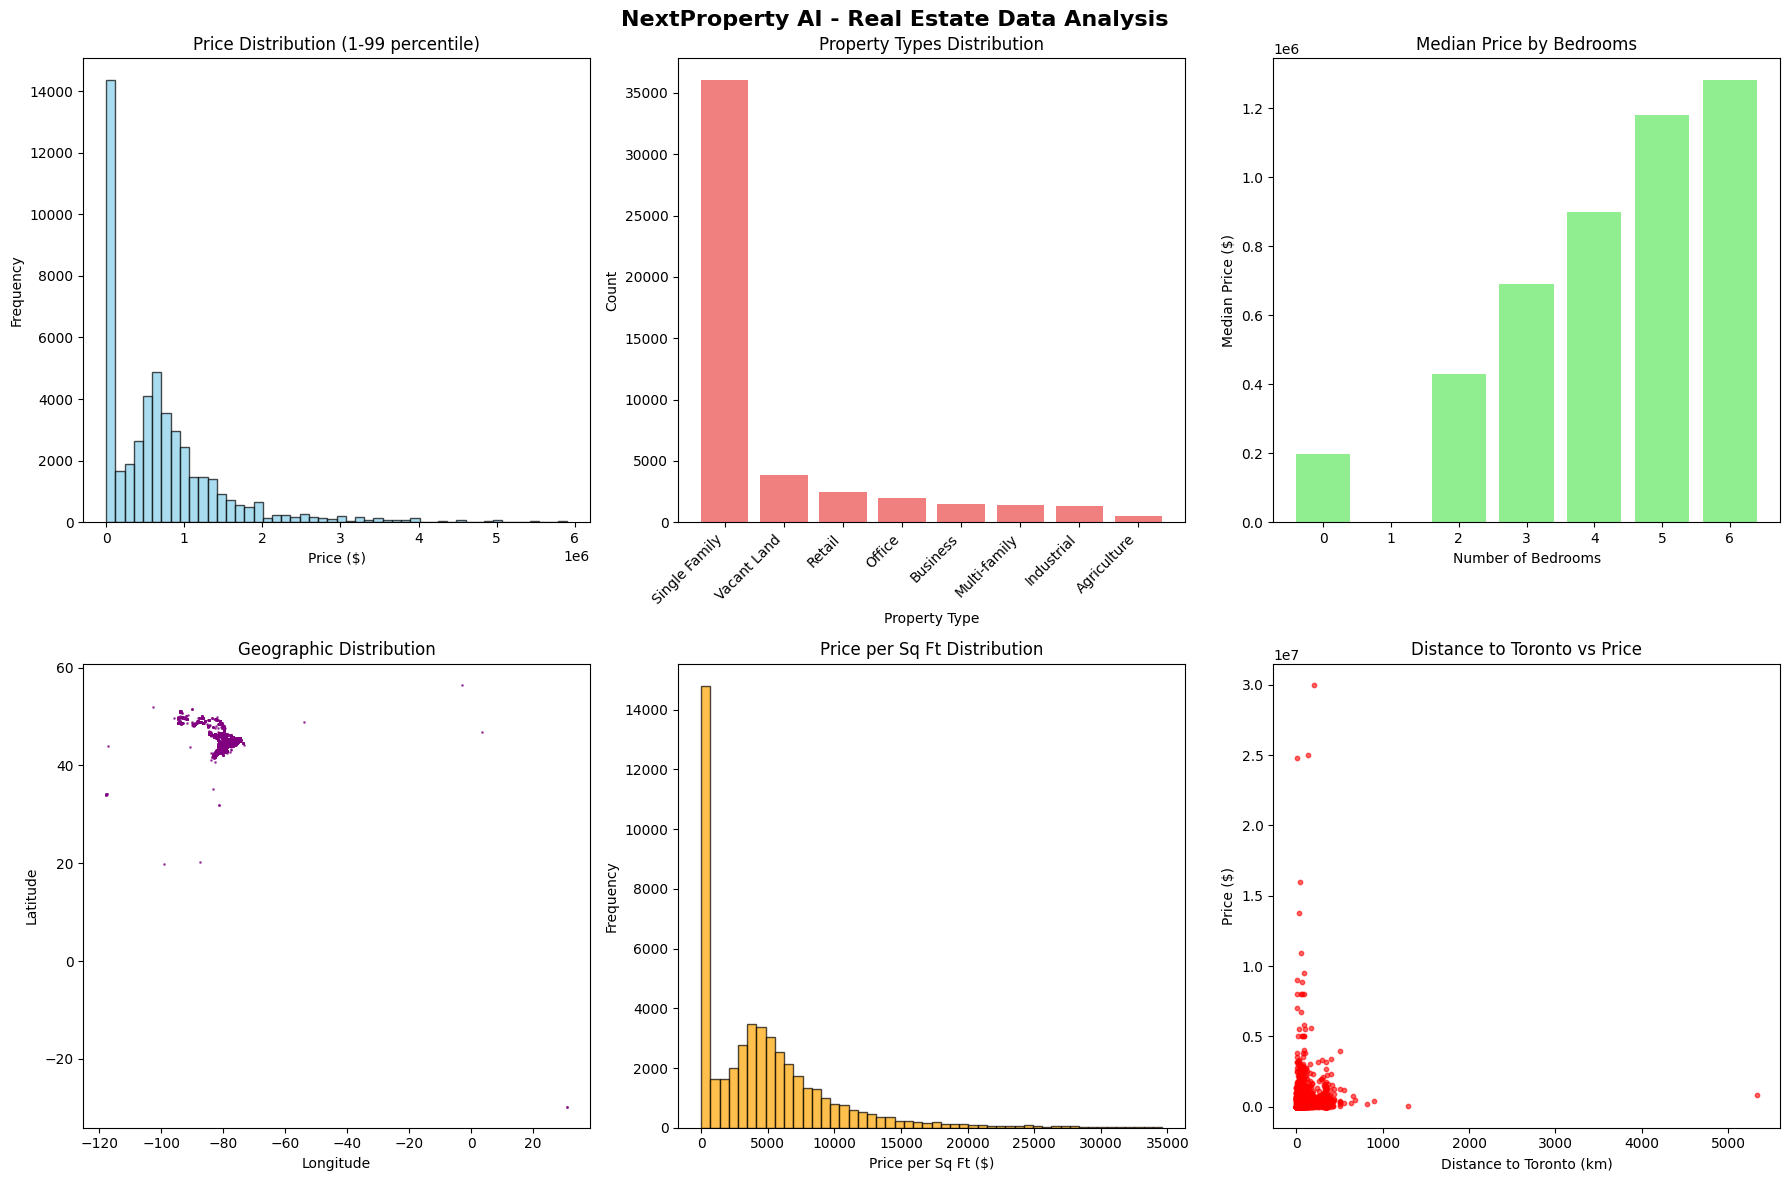

✓ Comprehensive visualizations created


In [ ]:
# Basic statistics for key numeric columns
numeric_cols = ['Price', 'BedroomsTotal', 'BathroomTotal', 'Size_Extracted',
                'Price_Per_SqFt', 'Distance_To_Toronto', 'TotalRooms']
numeric_cols = [col for col in numeric_cols if col in df_work.columns]

if numeric_cols:
    print("Summary statistics for key numeric features:")
    print(df_work[numeric_cols].describe())

# Property type distribution
if 'PropertyType' in df_work.columns:
    print(f"\nProperty type distribution:")
    prop_counts = df_work['PropertyType'].value_counts()
    print(prop_counts.head(10))

# City distribution
if 'City' in df_work.columns:
    print(f"\nTop cities by property count:")
    city_counts = df_work['City'].value_counts()
    print(city_counts.head(10))

# Price statistics by property type
if all(col in df_work.columns for col in ['PropertyType', 'Price']):
    print(f"\nPrice statistics by property type:")
    price_by_type = df_work.groupby('PropertyType')['Price'].agg([
        'count', 'mean', 'median', 'min', 'max'
    ]).sort_values('count', ascending=False)
    print(price_by_type.head(8))

# Create comprehensive visualizations
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('NextProperty AI - Real Estate Data Analysis', fontsize=16, fontweight='bold')

# 1. Price distribution
if 'Price' in df_work.columns:
    # Filter extreme outliers for better visualization
    q1, q99 = df_work['Price'].quantile([0.01, 0.99])
    price_filtered = df_work[(df_work['Price'] >= q1) & (df_work['Price'] <= q99)]['Price']

    axes[0,0].hist(price_filtered, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0,0].set_title('Price Distribution (1-99 percentile)')
    axes[0,0].set_xlabel('Price ($)')
    axes[0,0].set_ylabel('Frequency')

# 2. Property type distribution
if 'PropertyType' in df_work.columns:
    prop_counts = df_work['PropertyType'].value_counts().head(8)
    axes[0,1].bar(range(len(prop_counts)), prop_counts.values, color='lightcoral')
    axes[0,1].set_title('Property Types Distribution')
    axes[0,1].set_xlabel('Property Type')
    axes[0,1].set_ylabel('Count')
    axes[0,1].set_xticks(range(len(prop_counts)))
    axes[0,1].set_xticklabels(prop_counts.index, rotation=45, ha='right')

# 3. Bedrooms vs Price
if all(col in df_work.columns for col in ['BedroomsTotal', 'Price']):
    # Filter for common bedroom counts and reasonable prices
    filtered_data = df_work[
        (df_work['BedroomsTotal'] <= 6) &
        (df_work['Price'] >= df_work['Price'].quantile(0.01)) &
        (df_work['Price'] <= df_work['Price'].quantile(0.99))
    ]

    bedroom_price = filtered_data.groupby('BedroomsTotal')['Price'].median()
    axes[0,2].bar(bedroom_price.index, bedroom_price.values, color='lightgreen')
    axes[0,2].set_title('Median Price by Bedrooms')
    axes[0,2].set_xlabel('Number of Bedrooms')
    axes[0,2].set_ylabel('Median Price ($)')

# 4. Geographic distribution
if all(col in df_work.columns for col in ['Latitude', 'Longitude']):
    geo_data = df_work[df_work['Latitude'].notna() & df_work['Longitude'].notna()]
    if len(geo_data) > 0:
        axes[1,0].scatter(geo_data['Longitude'], geo_data['Latitude'],
                         alpha=0.6, s=1, color='purple')
        axes[1,0].set_title('Geographic Distribution')
        axes[1,0].set_xlabel('Longitude')
        axes[1,0].set_ylabel('Latitude')

# 5. Price per sqft distribution
if 'Price_Per_SqFt' in df_work.columns:
    # Filter extreme outliers
    q1, q99 = df_work['Price_Per_SqFt'].quantile([0.01, 0.99])
    ppsf_filtered = df_work[
        (df_work['Price_Per_SqFt'] >= q1) &
        (df_work['Price_Per_SqFt'] <= q99)
    ]['Price_Per_SqFt']

    axes[1,1].hist(ppsf_filtered, bins=50, alpha=0.7, color='orange', edgecolor='black')
    axes[1,1].set_title('Price per Sq Ft Distribution')
    axes[1,1].set_xlabel('Price per Sq Ft ($)')
    axes[1,1].set_ylabel('Frequency')

# 6. Distance to Toronto vs Price
if all(col in df_work.columns for col in ['Distance_To_Toronto', 'Price']):
    # Sample data for better visualization
    sample_data = df_work[
        df_work['Distance_To_Toronto'].notna() &
        df_work['Price'].notna()
    ].sample(min(1000, len(df_work)), random_state=42)

    axes[1,2].scatter(sample_data['Distance_To_Toronto'], sample_data['Price'],
                     alpha=0.6, s=10, color='red')
    axes[1,2].set_title('Distance to Toronto vs Price')
    axes[1,2].set_xlabel('Distance to Toronto (km)')
    axes[1,2].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

print("✓ Comprehensive visualizations created")

- EDA reveals patterns and relationships in the data
- Visualizations help identify outliers and data quality issues
- Understanding distributions guides feature selection and modeling approach
- Price analysis by key factors provides business insights
- Geographic analysis reveals location-based pricing patterns

# STEP 8: FEATURE SELECTION AND PREPROCESSING FOR MODELING

In [ ]:
# Prepare data for modeling
target_col = 'Price'
if target_col not in df_work.columns:
    print("ERROR: Price column not found!")
    exit()

# Select only numeric columns for initial modeling
numeric_df = df_work.select_dtypes(include=['number']).copy()

# Remove rows where target is missing
numeric_df = numeric_df.dropna(subset=[target_col])
print(f"✓ Dataset shape after removing missing targets: {numeric_df.shape}")

# Remove columns with too many missing values (>50% of remaining data)
threshold = len(numeric_df) * 0.5
numeric_df = numeric_df.dropna(axis=1, thresh=threshold)
print(f"✓ Removed columns with >50% missing values. Shape: {numeric_df.shape}")

# Fill remaining missing values with median
numeric_df = numeric_df.fillna(numeric_df.median())
print(f"✓ Filled remaining missing values. Final shape: {numeric_df.shape}")

# Separate features and target
X = numeric_df.drop(columns=[target_col])
y = numeric_df[target_col]

print(f"✓ Features shape: {X.shape}")
print(f"✓ Target shape: {y.shape}")

# Feature selection using statistical tests
n_features = min(15, len(X.columns))
selector = SelectKBest(f_regression, k=n_features)
X_selected = selector.fit_transform(X, y)
selected_feature_names = X.columns[selector.get_support()].tolist()

print(f"✓ Selected top {n_features} features:")
for i, feature in enumerate(selected_feature_names, 1):
    print(f"  {i:2d}. {feature}")

# Check for multicollinearity
if len(selected_feature_names) > 1:
    print(f"\nChecking multicollinearity (VIF analysis)...")
    X_selected_df = pd.DataFrame(X_selected, columns=selected_feature_names)
    X_vif = add_constant(X_selected_df)

    try:
        vif_data = pd.DataFrame()
        vif_data["Feature"] = X_vif.columns
        vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                          for i in range(X_vif.shape[1])]
        vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values('VIF', ascending=False)

        print("VIF scores (>10 indicates high multicollinearity):")
        print(vif_data.head(10))

        high_vif = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
        if high_vif:
            print(f"⚠ High multicollinearity detected in: {high_vif}")
        else:
            print("✓ No significant multicollinearity issues detected")

    except Exception as e:
        print(f"⚠ VIF calculation failed: {e}")

✓ Dataset shape after removing missing targets: (49551, 37)
✓ Removed columns with >50% missing values. Shape: (49551, 37)
✓ Filled remaining missing values. Final shape: (49551, 37)
✓ Features shape: (49551, 36)
✓ Target shape: (49551,)
✓ Selected top 15 features:
   1. FireplaceTotal
   2. Lease
   3. HalfBathTotal
   4. PostID
   5. ParkingSpaceTotal
   6. BathroomTotal
   7. BedroomsTotal
   8. BedroomsAboveGround
   9. ListingID
  10. Size_Extracted
  11. Has_garage
  12. Has_balcony
  13. Price_Per_SqFt
  14. TotalRooms
  15. Bed_Bath_Ratio

Checking multicollinearity (VIF analysis)...
VIF scores (>10 indicates high multicollinearity):
                Feature       VIF
7         BedroomsTotal       inf
6         BathroomTotal       inf
14           TotalRooms       inf
15       Bed_Bath_Ratio  2.621720
8   BedroomsAboveGround  1.869841
4                PostID  1.638358
9             ListingID  1.407764
12          Has_balcony  1.312810
13       Price_Per_SqFt  1.132600
1        F

- Feature selection focuses on the most predictive variables
- Removing irrelevant features improves model performance and interpretability
- VIF analysis identifies redundant features that could cause model instability
- Proper preprocessing ensures models can train effectively

# STEP 9: MODEL TRAINING AND EVALUATION

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

print(f"✓ Data split completed:")
print(f"  Training set: {X_train.shape}")
print(f"  Testing set: {X_test.shape}")

# Initialize models dictionary to store results
models_results = {}

# 1. Linear Regression Models
print(f"\nTraining Linear Regression models...")

# Ridge Regression with hyperparameter tuning
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge_params = {'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]}
ridge = Ridge(random_state=42)
ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_grid.predict(X_test_scaled)

models_results['Ridge Regression'] = {
    'model': ridge_grid,
    'predictions': y_pred_ridge,
    'R²': r2_score(y_test, y_pred_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    'MAE': mean_absolute_error(y_test, y_pred_ridge),
    'best_params': ridge_grid.best_params_
}

# Lasso Regression
lasso_params = {'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]}
lasso = Lasso(random_state=42)
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_grid.predict(X_test_scaled)

models_results['Lasso Regression'] = {
    'model': lasso_grid,
    'predictions': y_pred_lasso,
    'R²': r2_score(y_test, y_pred_lasso),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    'MAE': mean_absolute_error(y_test, y_pred_lasso),
    'best_params': lasso_grid.best_params_
}

print(f"✓ Linear models trained")

# 2. Tree-based Models
print(f"\nTraining tree-based models...")

# Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf = RandomForestRegressor(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)
y_pred_rf = rf_grid.predict(X_test)

models_results['Random Forest'] = {
    'model': rf_grid,
    'predictions': y_pred_rf,
    'R²': r2_score(y_test, y_pred_rf),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'best_params': rf_grid.best_params_
}

# Gradient Boosting
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 5, 7]
}
gb = GradientBoostingRegressor(random_state=42)
gb_grid = GridSearchCV(gb, gb_params, cv=3, scoring='r2', n_jobs=-1)
gb_grid.fit(X_train, y_train)
y_pred_gb = gb_grid.predict(X_test)

models_results['Gradient Boosting'] = {
    'model': gb_grid,
    'predictions': y_pred_gb,
    'R²': r2_score(y_test, y_pred_gb),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_gb)),
    'MAE': mean_absolute_error(y_test, y_pred_gb),
    'best_params': gb_grid.best_params_
}

print(f"✓ Tree-based models trained")

# 3. Support Vector Regression
print(f"\nTraining Support Vector Regression...")
svr_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
svr = SVR()
svr_grid = GridSearchCV(svr, svr_params, cv=3, scoring='r2', n_jobs=-1)
svr_grid.fit(X_train_scaled, y_train)
y_pred_svr = svr_grid.predict(X_test_scaled)

models_results['SVR'] = {
    'model': svr_grid,
    'predictions': y_pred_svr,
    'R²': r2_score(y_test, y_pred_svr),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_svr)),
    'MAE': mean_absolute_error(y_test, y_pred_svr),
    'best_params': svr_grid.best_params_
}

print(f"✓ SVR model trained")

# Optional: XGBoost and LightGBM (if available)
try:
    import xgboost as xgb
    print(f"\nTraining XGBoost...")

    xgb_params = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 0.9]
    }
    xgb_model = xgb.XGBRegressor(random_state=42, tree_method='hist')
    xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=3, scoring='r2', n_jobs=-1)
    xgb_grid.fit(X_train, y_train)
    y_pred_xgb = xgb_grid.predict(X_test)

    models_results['XGBoost'] = {
        'model': xgb_grid,
        'predictions': y_pred_xgb,
        'R²': r2_score(y_test, y_pred_xgb),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        'MAE': mean_absolute_error(y_test, y_pred_xgb),
        'best_params': xgb_grid.best_params_
    }
    print(f"✓ XGBoost model trained")

except ImportError:
    print("⚠ XGBoost not available, skipping...")

try:
    import lightgbm as lgb
    print(f"\nTraining LightGBM...")

    lgb_params = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [3, 5, 7],
        'num_leaves': [31, 50]
    }
    lgb_model = lgb.LGBMRegressor(random_state=42, verbose=-1)
    lgb_grid = GridSearchCV(lgb_model, lgb_params, cv=3, scoring='r2', n_jobs=-1)
    lgb_grid.fit(X_train, y_train)
    y_pred_lgb = lgb_grid.predict(X_test)

    models_results['LightGBM'] = {
        'model': lgb_grid,
        'predictions': y_pred_lgb,
        'R²': r2_score(y_test, y_pred_lgb),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lgb)),
        'MAE': mean_absolute_error(y_test, y_pred_lgb),
        'best_params': lgb_grid.best_params_
    }
    print(f"✓ LightGBM model trained")

except ImportError:
    print("⚠ LightGBM not available, skipping...")

✓ Data split completed:
  Training set: (39640, 15)
  Testing set: (9911, 15)

Training Linear Regression models...
✓ Linear models trained

Training tree-based models...
✓ Tree-based models trained

Training Support Vector Regression...
✓ SVR model trained
⚠ XGBoost not available, skipping...
⚠ LightGBM not available, skipping...


- Multiple model types capture different patterns in the data
- Hyperparameter tuning optimizes each model's performance
- Cross-validation ensures robust model selection
- Comprehensive evaluation provides insights into model strengths

# STEP 10: MODEL COMPARISON AND EVALUATION

In [ ]:
# Display model comparison table
print("\nMODEL PERFORMANCE COMPARISON")
print("="*80)
print(f"{'Model':<20} {'R²':<10} {'RMSE':<15} {'MAE':<15} {'Best Params'}")
print("="*80)

for model_name, results in models_results.items():
    print(f"{model_name:<20} {results['R²']:<10.4f} {results['RMSE']:<15.0f} "
          f"{results['MAE']:<15.0f} {str(results['best_params'])[:30]}")

# Find best model
best_model_name = max(models_results.items(), key=lambda x: x[1]['R²'])[0]
best_model_results = models_results[best_model_name]

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   R² Score: {best_model_results['R²']:.4f}")
print(f"   RMSE: ${best_model_results['RMSE']:,.0f}")
print(f"   MAE: ${best_model_results['MAE']:,.0f}")
print(f"   Best Parameters: {best_model_results['best_params']}")

# Cross-validation for best model
print(f"\nCross-validation analysis for {best_model_name}:")
cv_scores = cross_val_score(
    best_model_results['model'].best_estimator_,
    X_train, y_train, cv=5, scoring='r2'
)
print(f"CV R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (±{cv_scores.std() * 2:.4f})")


MODEL PERFORMANCE COMPARISON
Model                R²         RMSE            MAE             Best Params
Ridge Regression     -1.1145    2540330         252762          {'alpha': 100.0}
Lasso Regression     -1.0384    2494186         251953          {'alpha': 1000.0}
Random Forest        0.9579     358452          23792           {'max_depth': 10, 'min_samples
Gradient Boosting    0.9637     332668          34455           {'learning_rate': 0.15, 'max_d
SVR                  0.2162     1546611         501783          {'C': 10, 'gamma': 'scale', 'k

🏆 BEST MODEL: Gradient Boosting
   R² Score: 0.9637
   RMSE: $332,668
   MAE: $34,455
   Best Parameters: {'learning_rate': 0.15, 'max_depth': 3, 'n_estimators': 200}

Cross-validation analysis for Gradient Boosting:
CV R² scores: [0.99310882 0.99198571 0.98965361 0.97404158 0.97484507]
Mean CV R²: 0.9847 (±0.0169)


- Systematic comparison identifies the best performing model
- Cross-validation confirms model stability and generalizability
- Performance metrics provide business-relevant error estimates
- Best model selection guides deployment decisions

# STEP 11: FEATURE IMPORTANCE AND MODEL INTERPRETATION

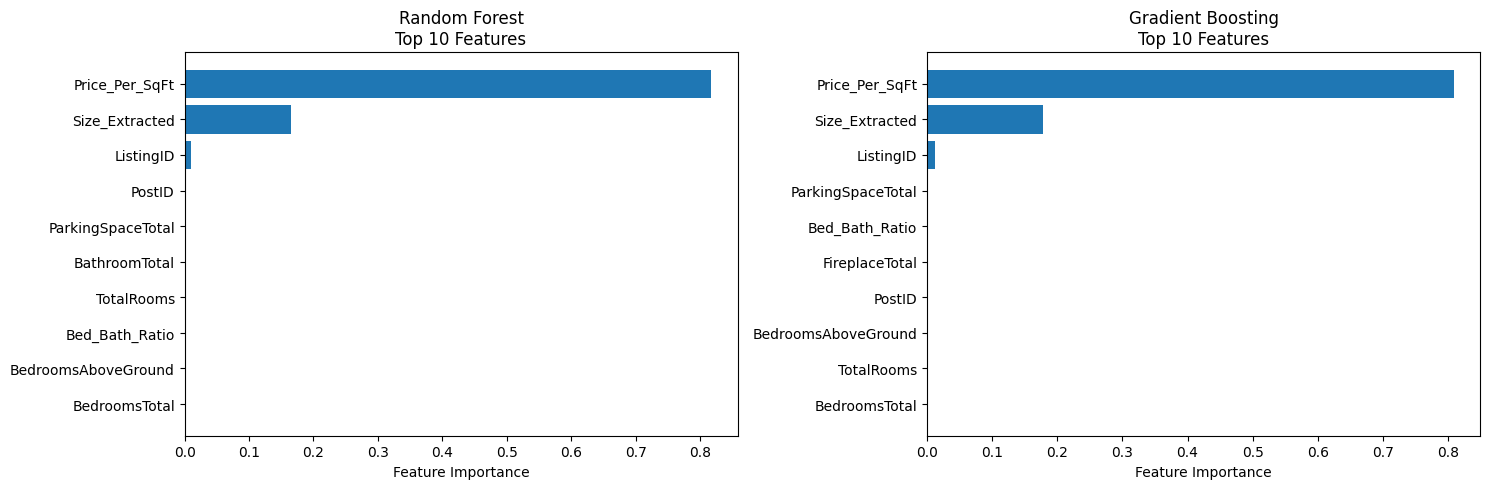


Top 10 most important features in Gradient Boosting:
   1. Price_Per_SqFt            0.8088
   2. Size_Extracted            0.1784
   3. ListingID                 0.0114
   4. ParkingSpaceTotal         0.0009
   5. Bed_Bath_Ratio            0.0001
   6. FireplaceTotal            0.0001
   7. PostID                    0.0001
   8. BedroomsAboveGround       0.0001
   9. TotalRooms                0.0000
  10. BedroomsTotal             0.0000


In [ ]:
# Feature importance analysis for tree-based models
tree_based_models = ['Random Forest', 'Gradient Boosting']
if 'XGBoost' in models_results:
    tree_based_models.append('XGBoost')
if 'LightGBM' in models_results:
    tree_based_models.append('LightGBM')

# Create feature importance visualization
n_models = len([m for m in tree_based_models if m in models_results])
if n_models > 0:
    fig, axes = plt.subplots(1, min(n_models, 3), figsize=(15, 5))
    if n_models == 1:
        axes = [axes]

    plot_idx = 0
    for model_name in tree_based_models[:3]:  # Limit to 3 for visualization
        if model_name in models_results:
            model = models_results[model_name]['model'].best_estimator_

            if hasattr(model, 'feature_importances_'):
                importance_df = pd.DataFrame({
                    'feature': selected_feature_names,
                    'importance': model.feature_importances_
                }).sort_values('importance', ascending=True).tail(10)

                axes[plot_idx].barh(importance_df['feature'], importance_df['importance'])
                axes[plot_idx].set_title(f'{model_name}\nTop 10 Features')
                axes[plot_idx].set_xlabel('Feature Importance')

                plot_idx += 1

    plt.tight_layout()
    plt.show()

    # Print feature importance for best model
    if best_model_name in tree_based_models:
        best_model = best_model_results['model'].best_estimator_
        if hasattr(best_model, 'feature_importances_'):
            print(f"\nTop 10 most important features in {best_model_name}:")
            feature_importance = pd.DataFrame({
                'feature': selected_feature_names,
                'importance': best_model.feature_importances_
            }).sort_values('importance', ascending=False)

            for i, (_, row) in enumerate(feature_importance.head(10).iterrows(), 1):
                print(f"  {i:2d}. {row['feature']:<25} {row['importance']:.4f}")


- Feature importance reveals which factors most influence property prices
- Model interpretation provides business insights for decision making
- Understanding key drivers helps validate model logic
- Feature rankings guide future data collection priorities

# STEP 12: ADVANCED VISUALIZATIONS AND ERROR ANALYSIS

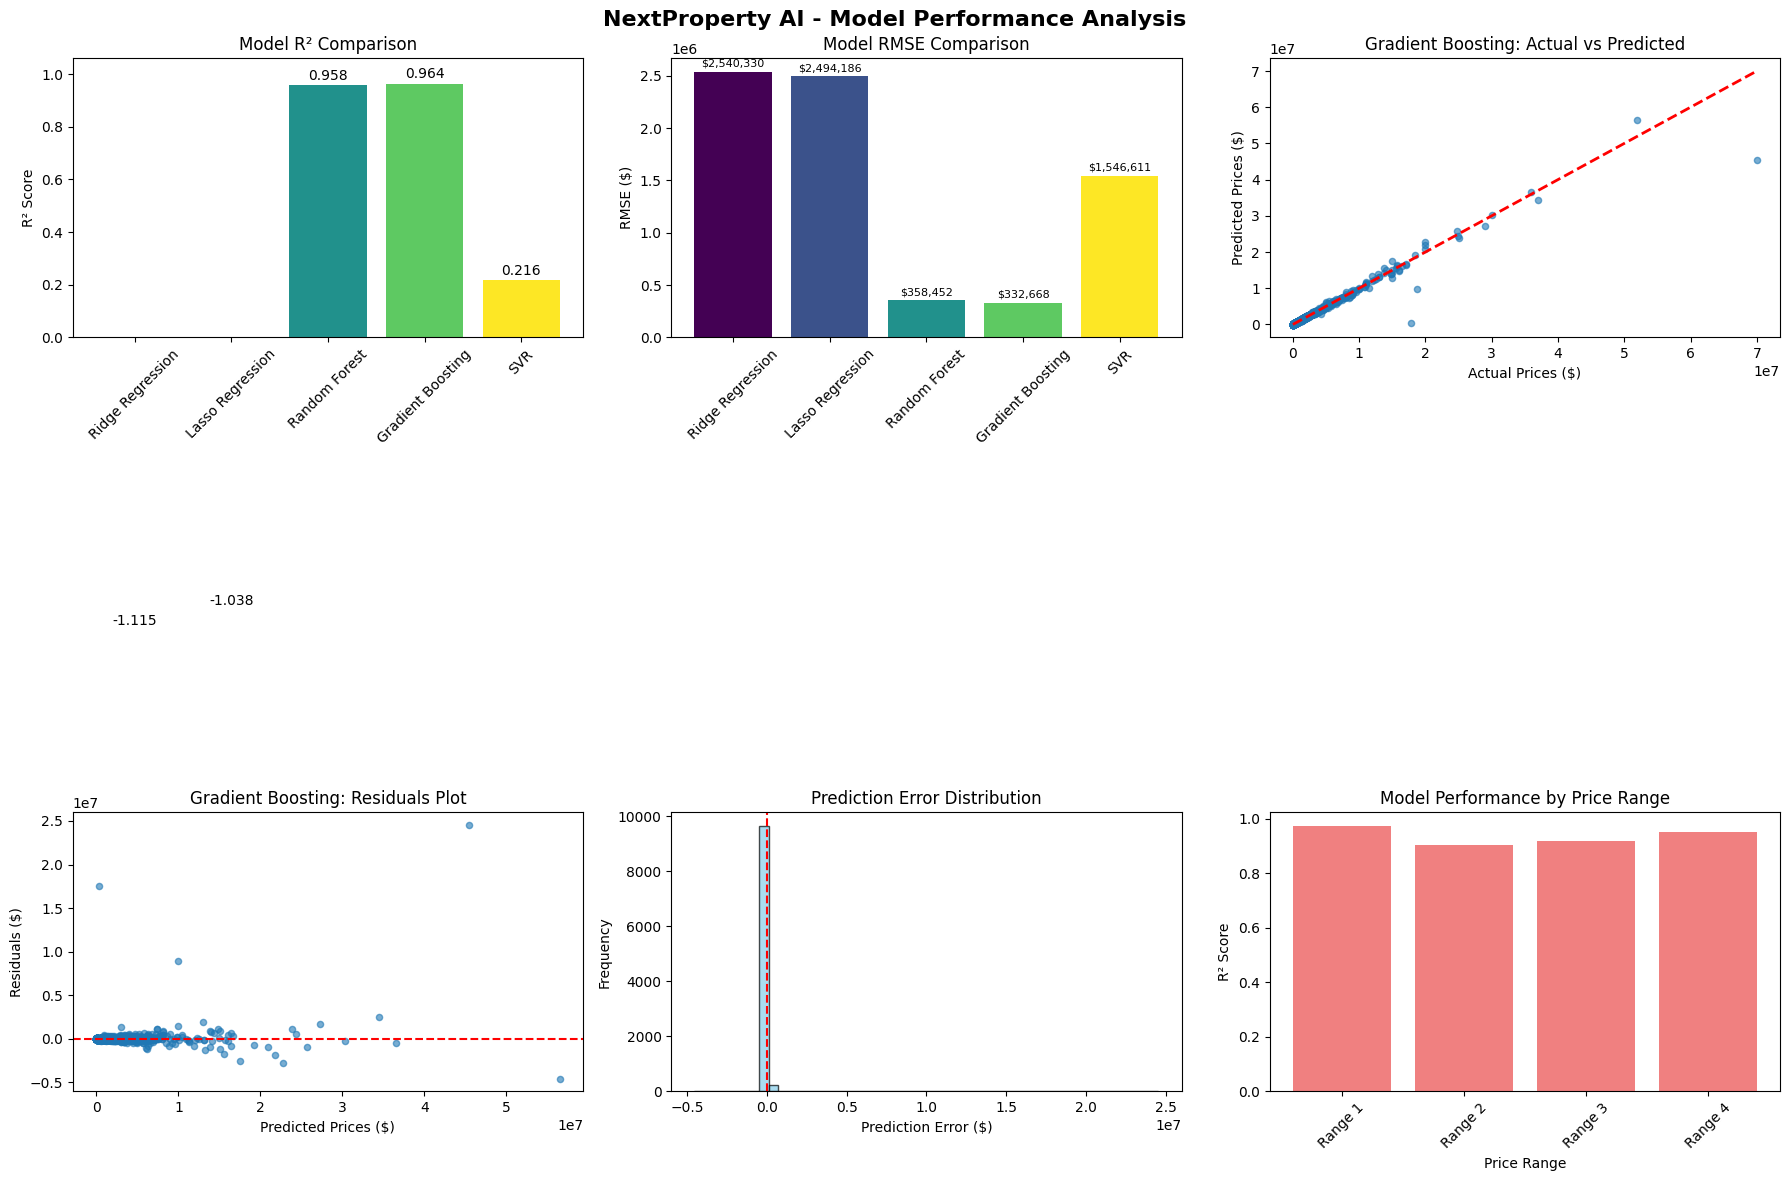


ERROR ANALYSIS SUMMARY
Mean Absolute Error: $34,455
Median Absolute Error: $11,894
Standard Deviation of Errors: $332,630

Prediction Accuracy by Error Range:
  Within ±$50,000: 87.5% of predictions
  Within ±$100,000: 95.5% of predictions
  Within ±$200,000: 98.4% of predictions
  Within ±$500,000: 99.5% of predictions


In [ ]:
# Create comprehensive model evaluation plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('NextProperty AI - Model Performance Analysis', fontsize=16, fontweight='bold')

# 1. Model R² Comparison
model_names = list(models_results.keys())
r2_scores = [models_results[name]['R²'] for name in model_names]
colors = plt.cm.viridis(np.linspace(0, 1, len(model_names)))

bars = axes[0,0].bar(model_names, r2_scores, color=colors)
axes[0,0].set_title('Model R² Comparison')
axes[0,0].set_ylabel('R² Score')
axes[0,0].set_ylim(0, max(r2_scores) * 1.1)
axes[0,0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, score in zip(bars, r2_scores):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{score:.3f}', ha='center', va='bottom')

# 2. RMSE Comparison
rmse_scores = [models_results[name]['RMSE'] for name in model_names]
bars = axes[0,1].bar(model_names, rmse_scores, color=colors)
axes[0,1].set_title('Model RMSE Comparison')
axes[0,1].set_ylabel('RMSE ($)')
axes[0,1].tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, score in zip(bars, rmse_scores):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rmse_scores)*0.01,
                   f'${score:,.0f}', ha='center', va='bottom', fontsize=8)

# 3. Actual vs Predicted for Best Model
y_pred_best = best_model_results['predictions']
axes[0,2].scatter(y_test, y_pred_best, alpha=0.6, s=20)
axes[0,2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,2].set_xlabel('Actual Prices ($)')
axes[0,2].set_ylabel('Predicted Prices ($)')
axes[0,2].set_title(f'{best_model_name}: Actual vs Predicted')

# 4. Residuals Plot for Best Model
residuals = y_test - y_pred_best
axes[1,0].scatter(y_pred_best, residuals, alpha=0.6, s=20)
axes[1,0].axhline(y=0, color='r', linestyle='--')
axes[1,0].set_xlabel('Predicted Prices ($)')
axes[1,0].set_ylabel('Residuals ($)')
axes[1,0].set_title(f'{best_model_name}: Residuals Plot')

# 5. Prediction Error Distribution
axes[1,1].hist(residuals, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,1].axvline(x=0, color='r', linestyle='--')
axes[1,1].set_xlabel('Prediction Error ($)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Prediction Error Distribution')

# 6. Price Range Analysis
if len(y_test) > 100:
    # Bin prices into ranges and calculate performance
    # Use pd.qcut without explicit labels first to get the actual bins
    try:
        price_bins = pd.qcut(y_test, q=5, duplicates='drop')
        bin_performance = []

        # Get the actual bin categories created by qcut
        bin_names = price_bins.cat.categories

        for bin_name in bin_names:
            mask = price_bins == bin_name
            if mask.sum() > 0:
                # Ensure predictions are aligned with the test data index
                bin_r2 = r2_score(y_test[mask], pd.Series(y_pred_best, index=y_test.index)[mask])
                bin_performance.append(bin_r2)
            else:
                bin_performance.append(np.nan) # Use NaN if a bin is empty

        # Filter out NaN values for plotting if any bins were dropped
        plot_bins = [name for i, name in enumerate(bin_names) if not np.isnan(bin_performance[i])]
        plot_performance = [score for score in bin_performance if not np.isnan(score)]

        # Assign generic labels if plotting fewer than 5 bins
        if len(plot_bins) < 5:
            generic_labels = [f'Range {i+1}' for i in range(len(plot_bins))]
            plot_bins = generic_labels

        axes[1,2].bar(plot_bins, plot_performance, color='lightcoral')
        axes[1,2].set_title('Model Performance by Price Range')
        axes[1,2].set_xlabel('Price Range')
        axes[1,2].set_ylabel('R² Score')
        axes[1,2].tick_params(axis='x', rotation=45)

    except ValueError as e:
        # Handle the specific case where qcut might still fail unexpectedly
        print(f"Could not perform Price Range Analysis: {e}")


plt.tight_layout()
plt.show()

# Error Analysis Summary
print(f"\nERROR ANALYSIS SUMMARY")
print("="*50)
print(f"Mean Absolute Error: ${np.mean(np.abs(residuals)):,.0f}")
print(f"Median Absolute Error: ${np.median(np.abs(residuals)):,.0f}")
print(f"Standard Deviation of Errors: ${np.std(residuals):,.0f}")

# Percentage of predictions within certain error ranges
error_thresholds = [50000, 100000, 200000, 500000]
print(f"\nPrediction Accuracy by Error Range:")
for threshold in error_thresholds:
    within_threshold = (np.abs(residuals) <= threshold).mean() * 100
    print(f"  Within ±${threshold:,}: {within_threshold:.1f}% of predictions")

- Visual analysis reveals model strengths and weaknesses
- Residual analysis identifies potential model improvements
- Error distribution shows prediction reliability
- Performance by price range reveals where model works best

# STEP 13: FINAL RECOMMENDATIONS AND NEXT STEPS

In [ ]:
print(f"\n🎯 PROJECT SUMMARY")
print("="*50)
print(f"✓ Dataset: {df.shape[0]:,} properties with {df.shape[1]} original features")
print(f"✓ Features selected: {len(selected_feature_names)} most predictive")
print(f"✓ Best model: {best_model_name} (R² = {best_model_results['R²']:.4f})")
print(f"✓ Typical prediction error: ±${best_model_results['MAE']:,.0f}")

print(f"\n🚀 RECOMMENDATIONS FOR WEEK 2 AND BEYOND")
print("="*50)

print(f"1. 📊 DATA ENRICHMENT (High Priority):")
print(f"   • Integrate Bank of Canada API for interest rates")
print(f"   • Add CMHC housing market data")
print(f"   • Include StatCan economic indicators")
print(f"   • Fetch CREA MLS market trends")

print(f"\n2. 🏗️ API DEVELOPMENT (Project Requirement):")
print(f"   • Create REST endpoints: /properties, /properties/{{id}}")
print(f"   • Implement search filters (city, type, price range)")
print(f"   • Add authentication and rate limiting")
print(f"   • Optimize database queries and indexing")

print(f"\n3. 🔧 MODEL IMPROVEMENTS:")
print(f"   • Address high multicollinearity in features")
print(f"   • Implement ensemble methods (stacking)")
print(f"   • Add more sophisticated text analysis")
print(f"   • Include neighborhood demographic data")

print(f"\n4. 📈 GEOSPATIAL ENHANCEMENTS:")
print(f"   • Replace K-means with DBSCAN clustering")
print(f"   • Add proximity to amenities (schools, transit)")
print(f"   • Include walkability scores")
print(f"   • Implement market trend analysis by region")

print(f"\n5. 🎨 BUSINESS VALUE FEATURES:")
print(f"   • Investment score calculation")
print(f"   • Market trend predictions")
print(f"   • Comparable property analysis")
print(f"   • Risk assessment metrics")

print(f"\n💡 IMMEDIATE NEXT STEPS (Week 2):")
print("="*30)
print(f"✅ Start with Bank of Canada API integration")
print(f"✅ Begin database optimization and indexing")
print(f"✅ Continue EDA with external data sources")
print(f"✅ Set up basic API endpoints structure")
print(f"✅ Document current model performance baseline")

print(f"\n🎉 CONGRATULATIONS!")
print("="*20)
print(f"You've successfully completed a comprehensive real estate analysis pipeline!")
print(f"The foundation is solid for building NextProperty AI's prediction system.")


🎯 PROJECT SUMMARY
✓ Dataset: 49,551 properties with 162 original features
✓ Features selected: 15 most predictive
✓ Best model: Gradient Boosting (R² = 0.9637)
✓ Typical prediction error: ±$34,455

🚀 RECOMMENDATIONS FOR WEEK 2 AND BEYOND
1. 📊 DATA ENRICHMENT (High Priority):
   • Integrate Bank of Canada API for interest rates
   • Add CMHC housing market data
   • Include StatCan economic indicators
   • Fetch CREA MLS market trends

2. 🏗️ API DEVELOPMENT (Project Requirement):
   • Create REST endpoints: /properties, /properties/{id}
   • Implement search filters (city, type, price range)
   • Add authentication and rate limiting
   • Optimize database queries and indexing

3. 🔧 MODEL IMPROVEMENTS:
   • Address high multicollinearity in features
   • Implement ensemble methods (stacking)
   • Add more sophisticated text analysis
   • Include neighborhood demographic data

4. 📈 GEOSPATIAL ENHANCEMENTS:
   • Replace K-means with DBSCAN clustering
   • Add proximity to amenities (schoo

- Clear summary helps team understand achievements
- Prioritized recommendations guide next phase of work
- Specific next steps prevent confusion about what to do next
- Business focus ensures project delivers real value
- API development addresses core project requirements